Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


Importing the Datasets

In [ ]:
sets = pd.read_csv("data/sets.csv")
themes = pd.read_csv("data/themes.csv")


In [3]:
sets.head()


,set_num,name,year,theme_id,num_parts
0,001-1,Gears,1965,1,43
1,0011-2,Town Mini-Figures,1979,67,12
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0
3,0012-1,Space Mini-Figures,1979,143,12
4,0013-1,Space Mini-Figures,1979,143,12


In [4]:
themes.head()

,id,name,parent_id
0,1,Technic,NaN
1,3,Competition,1.0
2,4,Expert Builder,1.0
3,16,RoboRiders,1.0
4,17,Speed Slammers,1.0


Combining Datasets

In [5]:
combined = pd.merge(sets,themes, left_on = "theme_id", right_on = "id", how = "inner")

In [6]:
combined.head()

,set_num,name_x,year,theme_id,num_parts,id,name_y,parent_id
0,001-1,Gears,1965,1,43,1,Technic,NaN
1,0011-2,Town Mini-Figures,1979,67,12,67,Classic Town,50.0
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0,199,Lion Knights,186.0
3,0012-1,Space Mini-Figures,1979,143,12,143,Supplemental,126.0
4,0013-1,Space Mini-Figures,1979,143,12,143,Supplemental,126.0


In [7]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18966 entries, 0 to 18965
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   set_num    18966 non-null  object 
 1   name_x     18966 non-null  object 
 2   year       18966 non-null  int64  
 3   theme_id   18966 non-null  int64  
 4   num_parts  18966 non-null  int64  
 5   id         18966 non-null  int64  
 6   name_y     18966 non-null  object 
 7   parent_id  8676 non-null   float64
dtypes: float64(1), int64(4), object(3)
memory usage: 1.2+ MB


In [8]:
combined.rename(columns = {"name_x" : "sets_name",
                           "name_y" : "themes_name"}, inplace = True
                           )



In [9]:
combined.head()

,set_num,sets_name,year,theme_id,num_parts,id,themes_name,parent_id
0,001-1,Gears,1965,1,43,1,Technic,NaN
1,0011-2,Town Mini-Figures,1979,67,12,67,Classic Town,50.0
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0,199,Lion Knights,186.0
3,0012-1,Space Mini-Figures,1979,143,12,143,Supplemental,126.0
4,0013-1,Space Mini-Figures,1979,143,12,143,Supplemental,126.0


In [10]:
combined.describe()

,year,theme_id,num_parts,id,parent_id
count,18966.000000,18966.000000,18966.000000,18966.000000,8676.000000
mean,2006.391174,407.592850,159.718180,407.592850,358.297372
std,13.782708,197.014436,397.254948,197.014436,200.514402
min,1949.000000,1.000000,0.000000,1.000000,1.000000
25%,2000.000000,246.000000,6.000000,246.000000,186.000000
50%,2010.000000,494.000000,35.500000,494.000000,458.000000
75%,2017.000000,524.000000,145.000000,524.000000,504.000000
max,2022.000000,719.000000,11695.000000,719.000000,697.000000


Dropping Columns that are not required for further analysis

In [11]:
combined.drop(columns= ["parent_id","id"], inplace = True)


In [12]:
combined.head()

,set_num,sets_name,year,theme_id,num_parts,themes_name
0,001-1,Gears,1965,1,43,Technic
1,0011-2,Town Mini-Figures,1979,67,12,Classic Town
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0,Lion Knights
3,0012-1,Space Mini-Figures,1979,143,12,Supplemental
4,0013-1,Space Mini-Figures,1979,143,12,Supplemental


Checking for Null Values

In [13]:
combined['year'].isnull().sum()

np.int64(0)

In [14]:
combined['sets_name'].isnull().sum()

np.int64(0)

In [15]:
combined['year'].min()

np.int64(1949)

In [16]:
combined['year'].max()

np.int64(2022)

In [17]:
combined.groupby('year').size()

year
1949       5
1950       6
1953       4
1954      14
1955      29
        ... 
2018     871
2019     939
2020     933
2021    1088
2022     341
Length: 72, dtype: int64

Attention: As per the output of the "combined.groupby('year').size()", year 2022 seems incomplete, Removing it from the analysis 
 

In [18]:
combined.tail()

,set_num,sets_name,year,theme_id,num_parts,themes_name
18961,XWING-1,Mini X-Wing Fighter,2019,158,60,Star Wars
18962,XWING-2,X-Wing Trench Run,2019,158,52,Star Wars
18963,YODACHRON-1,Yoda Chronicles Promotional Set,2013,158,413,Star Wars
18964,YTERRIER-1,Yorkshire Terrier,2018,598,0,Promotional
18965,ZX8000-1,ZX 8000 LEGO Sneaker,2020,501,0,Gear


Removing Year 2022 from the analysis 

In [19]:
combined_no2022 = combined[combined['year'] != 2022]

In [20]:
(combined['year'] != 2022).sum()

np.int64(18625)

In [21]:
combined_no2022.head()

,set_num,sets_name,year,theme_id,num_parts,themes_name
0,001-1,Gears,1965,1,43,Technic
1,0011-2,Town Mini-Figures,1979,67,12,Classic Town
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0,Lion Knights
3,0012-1,Space Mini-Figures,1979,143,12,Supplemental
4,0013-1,Space Mini-Figures,1979,143,12,Supplemental


Verifying the Removal

In [22]:
combined_no2022.groupby('year').size()

year
1949       5
1950       6
1953       4
1954      14
1955      29
        ... 
2017     867
2018     871
2019     939
2020     933
2021    1088
Length: 71, dtype: int64

In [23]:
theme_year = combined_no2022.groupby(['themes_name', 'year']).size()

In [24]:
combined_no2022.groupby('themes_name').size()

themes_name
12V                 52
4 Juniors           23
4.5V                86
9V                 100
Action Wheelers      9
                  ... 
X-Pod               24
Xtra                19
Znap                19
Zooters              3
eLAB                 3
Length: 355, dtype: int64

In [25]:
combined_no2022.groupby('themes_name').value_counts()

themes_name  set_num  sets_name                                                 year  theme_id  num_parts
12V          702-1    12V Motor with Accessories Pack                           1969  234       27           1
             703-1    12V Replacement Electric Motor                            1969  234       1            1
             704-1    12V Sleeper (Track) Contacts for Old Motor Type I and II  1969  234       2            1
             705-1    Motor Bushings                                            1969  234       4            1
             706-1    12V Rail Contact Wire with Transformer Connector          1969  234       2            1
                                                                                                            ..
Zooters      3264-1   Tez                                                       2001  666       9            1
             3265-1   Wazo                                                      2001  666       6            1
eLAB  

In [26]:
combined_no2022['themes_name'].value_counts()

themes_name
Gear                   2048
Star Wars               818
Technic                 687
Key Chain               578
Friends                 471
                       ... 
The Powerpuff Girls       2
Adventurers               1
Legoland                  1
Mini                      1
Aquazone                  1
Name: count, Length: 355, dtype: int64

Removing columns that are not required for the KMeans Analysis

In [27]:
combined_kmeans = combined_no2022.drop(columns=["set_num","sets_name","theme_id"])

In [28]:
combined_kmeans.head()

,year,num_parts,themes_name
0,1965,43,Technic
1,1979,12,Classic Town
2,1987,0,Lion Knights
3,1979,12,Supplemental
4,1979,12,Supplemental


In [29]:
features = combined_kmeans[["year","num_parts"]]

In [30]:
features.describe()

,year,num_parts
count,18625.000000,18625.000000
mean,2006.105396,158.002685
std,13.744040,393.462039
min,1949.000000,0.000000
25%,2000.000000,6.000000
50%,2010.000000,35.000000
75%,2017.000000,144.000000
max,2021.000000,11695.000000


Implementing Standard Scaler to scale the values to a common range

In [31]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [32]:
scaled_features[:5]

array([[-2.99086004, -0.29229191],
       [-1.97220933, -0.37108181],
       [-1.39012322, -0.40158112],
       [-1.97220933, -0.37108181],
       [-1.97220933, -0.37108181]])

In [33]:
print(scaled_features.mean())
scaled_features.std()

-3.6166148375869795e-16


np.float64(1.0)

In [34]:
scaled_features.mean(axis = 0)

array([-7.44686937e-16,  2.13639695e-17])

In [35]:
scaled_features.std(axis = 0)

array([1., 1.])

Calculating k value for analysis - Elbow Method

In [36]:
inertias = []
for k in range(1,11):
    model = KMeans(n_clusters = k).fit(scaled_features)
    inertias.append(model.inertia_)


In [37]:
inertias

[37250.000000000015,
 24597.79641411775,
 14809.25815158978,
 10853.52514640736,
 7486.672146106376,
 5884.084915437028,
 4935.075695902742,
 4122.395511635692,
 4128.937537467433,
 3131.4371531151555]

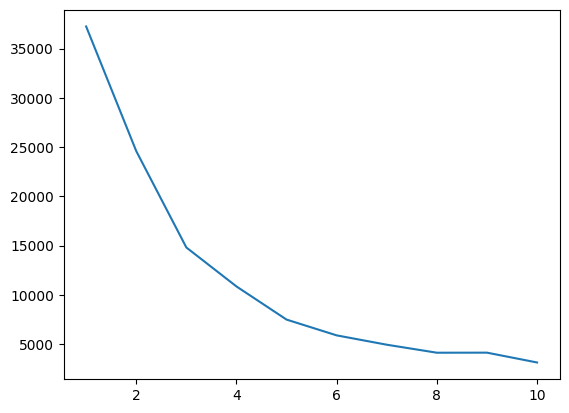

In [38]:
plt.plot(range(1,11),inertias)

K Means Algorithm (From the above plot, value of K = 6)

In [39]:
lego_cluster = KMeans(n_clusters = 6).fit(scaled_features)

In [40]:
lego_cluster

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [41]:
lego_cluster.cluster_centers_

array([[ 0.45149655,  1.40424241],
       [-2.07588575, -0.18530088],
       [ 0.79269972, 13.01255286],
       [ 0.56698654,  4.82206446],
       [-0.37867091, -0.22020518],
       [ 0.70119093, -0.23546536]])

In [42]:
reverse_scaled = scaler.inverse_transform(lego_cluster.cluster_centers_)

In [43]:
reverse_scaled

array([[2012.31061599,  710.50393185],
       [1977.57510549,   85.09578059],
       [2017.        , 5277.81081081],
       [2013.89787234, 2055.25106383],
       [2000.90106762,   71.36263345],
       [2015.74233337,   65.3584927 ]])

In [44]:
lego_cluster.labels_

array([1, 1, 1, ..., 0, 5, 5], shape=(18625,), dtype=int32)

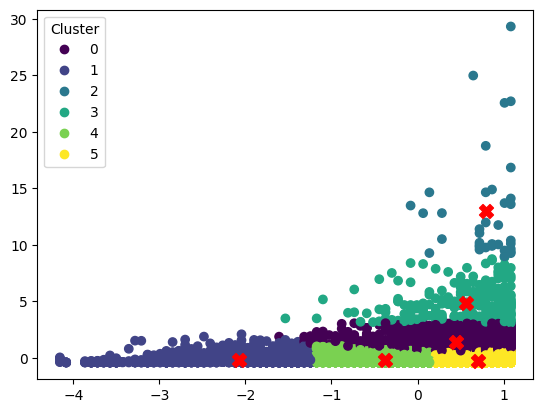

In [45]:
scatter = plt.scatter(scaled_features[:,0],scaled_features[:,1], c = lego_cluster.labels_)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.scatter(lego_cluster.cluster_centers_[:,0], lego_cluster.cluster_centers_[:,1], marker = "X", s = 100, c = 'r')

Final Analysis

Lego has expanded its business in all the domains of different size of sets. This is very clear from the 4 final clusters from the year 2012 to 2016 where the number of parts is varying drastically from 100s to 5000s. This confirms that the expansion is not in a particular area rather across the board. However, in the initial year, Lego focus was more on sets with less number of parts and less on mega sets but that has changed now. One last thing worth noting is that ~13% of the dataset predates 1990, spanning over 40 years of LEGO's early history — likely why clustering only surfaces one broad 'early/small' group rather than finer distinctions within that era.